#kagggleのタイタニックの課題のテンプレート



#事前準備

まず，事前準備として，kaggleから，タイタニックのデータ(train.csv, test,csv, gender_submission.csv)をダウンロードし，googleドライブ上にコピーしてください．

# Google Driveへの接続，ライブラリの読み込み
このコードで，Google Driveのファイルの読み取り，書き込みができるようになります．「Google ドライブのファイルへのアクセスを許可しますか？」と聞かれるので，「Googleドライブに接続」を選択し，「次へ」，「続行」を選択してください．

In [1]:
#Google Driveへの接続
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


このコードでは,必要なライブラリをimportしています.





importするライブラリは, Numpy(計算用), Pandas(表データ管理), matplotlibとseaborn(グラフ作成),  sklean(AI学習用ツール) です．

In [2]:
#Numpy
import numpy as np
#Pandas
import pandas as pd
#Pandasの中にある表管理の機能
from pandas import DataFrame, Series
#matplotlib
import matplotlib.pyplot as plt
#seaborn
import seaborn as sns

#学習する時にデータを分割する用のライブラリ
from sklearn.model_selection import train_test_split
#学習モデル(ランダムフォレスト)
from sklearn.ensemble import RandomForestClassifier
#交差検証用
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
#ラベルエンコーディング用
from sklearn.preprocessing import OrdinalEncoder


import warnings

warnings.filterwarnings('ignore')



ドライブからデータを読み込みpamdasのデータフレームに入れます．path="～"の部分に，ダウンロードしたデータがあるドライブのパスを入れてください．



ここで，train.csvは予測のために与えられたデータで，test.csvは実際に予測する対象のデータです（なのでtest.csvには，答えであるSurvivedの欄がありません）

In [3]:
#dfリセット
path =  '/content/drive/MyDrive/kaggle/titanic/'

df = pd.read_csv(path + 'train.csv')
df_test = pd.read_csv(path + 'test.csv')

ここでは，読み込んだデータの大きさを確認しています．

In [ ]:
# #データの大きさ確認用
print('訓練データのデータ数は{}、変数は{}種類です。'.format(df.shape[0], df.shape[1]))
print('テストデータのデータ数は{}、変数は{}種類です。'.format(df_test.shape[0], df_test.shape[1]))

訓練データのデータ数は891、変数は12種類です。
テストデータのデータ数は418、変数は11種類です。


次に，データの中身（先頭部分）を見て，データがどんな内容か確認しています．

In [5]:
#データの中身確認用
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


欠損値（値がないところ）がそれぞれにいくつあるか確認しています

In [6]:
#欠損値（null）確認用
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


データをより詳しく見るため，データの可視化を行っています．
ここでは，例として年齢と生存率の関係を見ています．

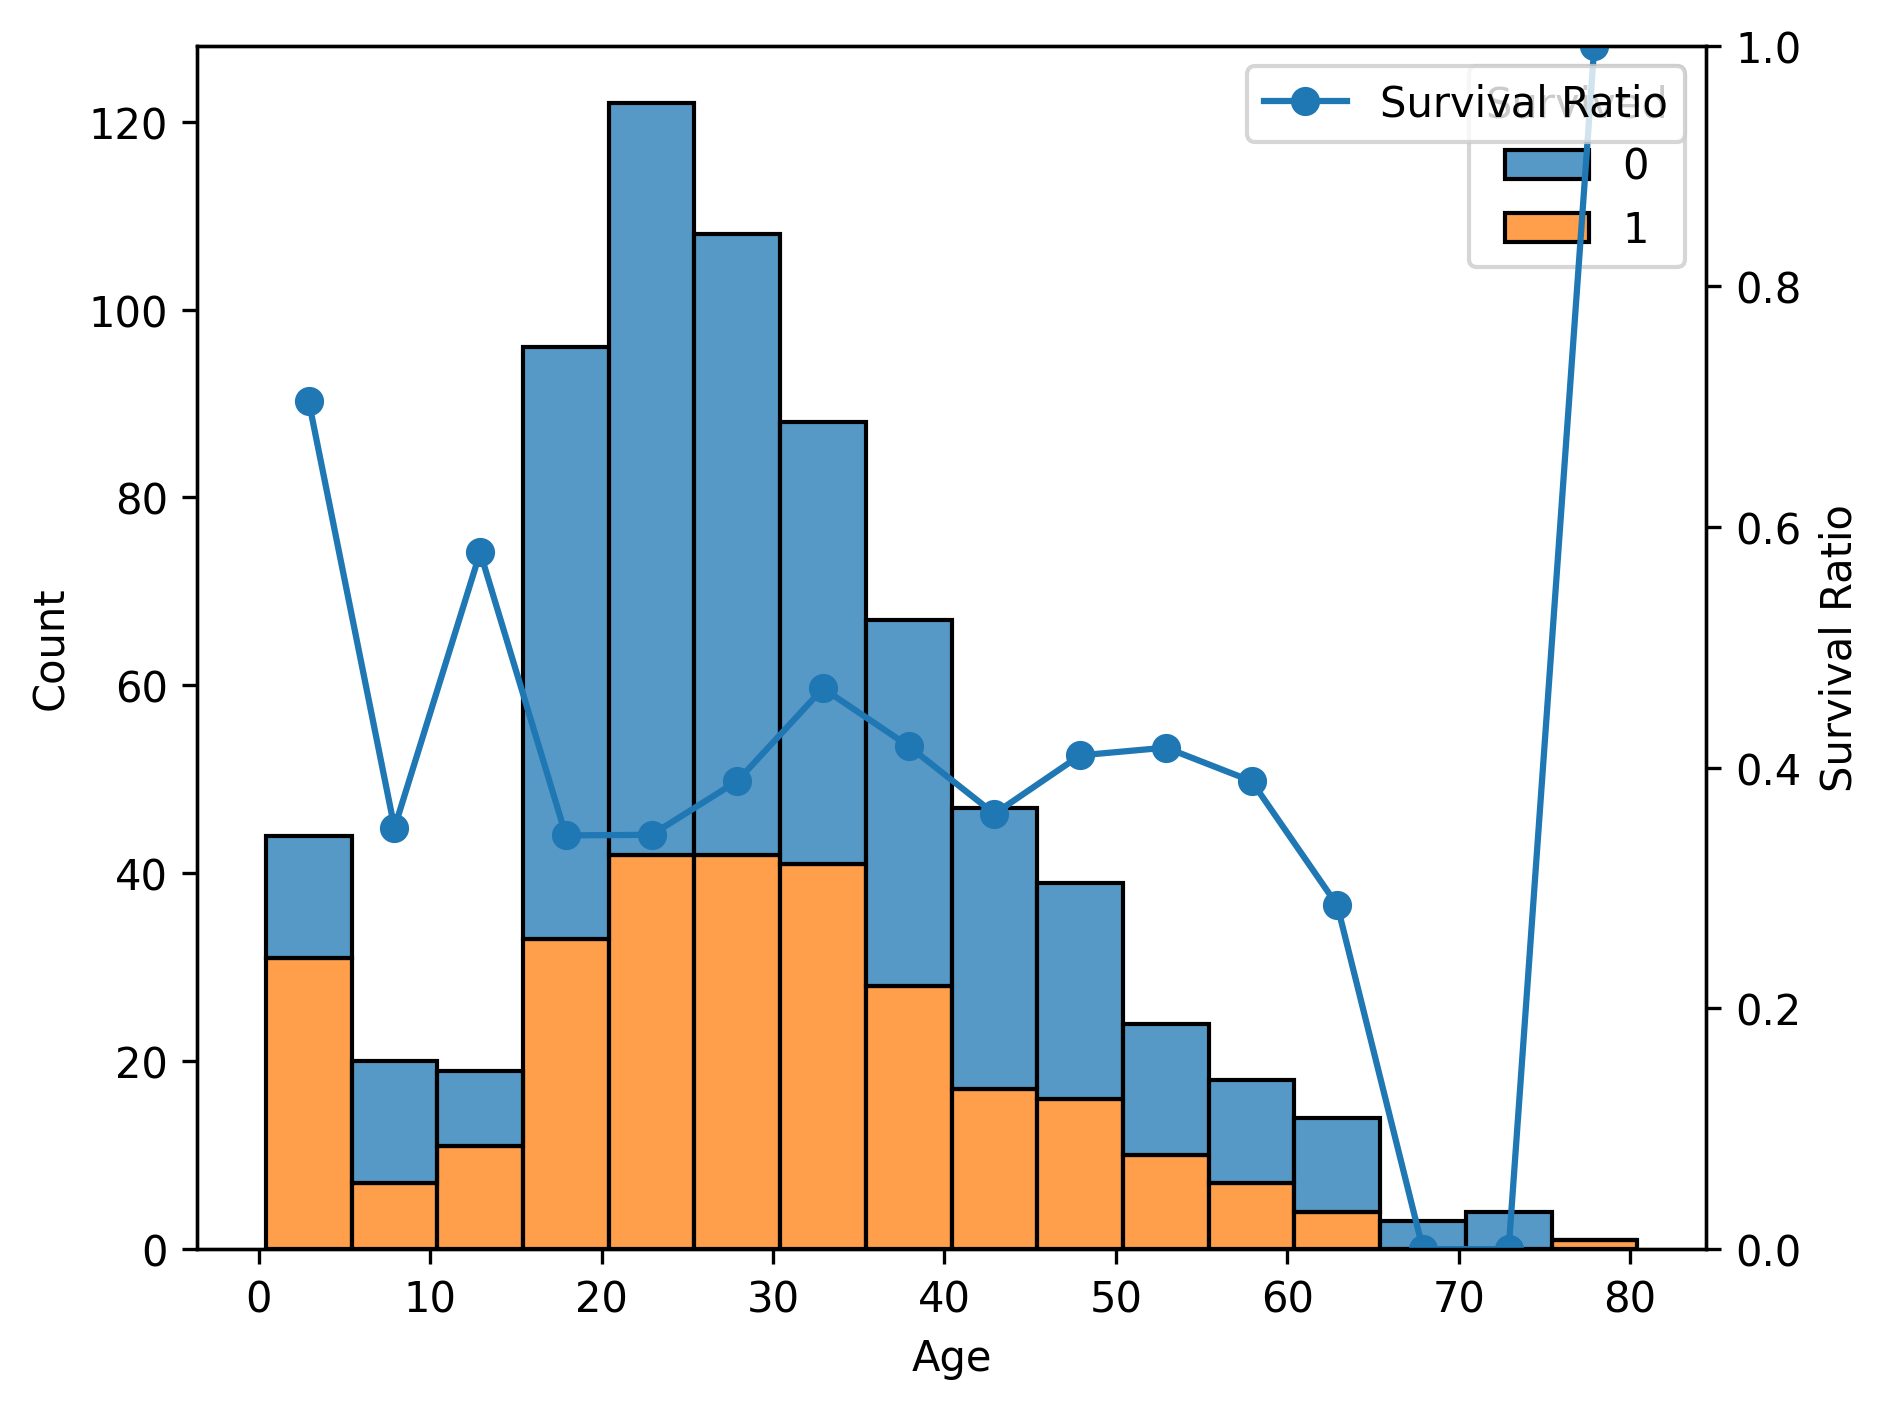

In [ ]:
#データの形確認用

#年齢別の生存数，生存率（例）
# ビンを定義
bin_width = 5
bins = np.arange(df["Age"].min(), df["Age"].max() + bin_width, bin_width)
# df["Age"].min()→データの最小値（例: 0）　df["Age"].max() + bin_width ➔ データの最大値 ＋ 5
# ヒストグラム描画
fig, ax = plt.subplots(dpi=300)
sns.histplot(
    data=df,
    x="Age",
    hue="Survived",
    multiple="stack",
    bins=bins,
    ax=ax
)

#一時変数でビンごとの生存率を計算
age_bins = pd.cut(df["Age"], bins=bins, include_lowest=True)
grouped = pd.crosstab(age_bins, df["Survived"])
ratio = grouped[1] / (grouped[0] + grouped[1])
#ビンの中心を取得
bin_centers = [interval.mid for interval in ratio.index]
#副軸に折れ線をプロット
ax2 = ax.twinx()
ax2.plot(bin_centers, ratio, marker="o", linestyle="-", label="Survival Ratio")
ax2.set_ylabel("Survival Ratio")
ax2.set_ylim(0, 1)
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

上のグラフから右に引きずる形だと分かったので，高い年齢の外れ値をnullにすることで処理します．

In [8]:
#外れ値処理
#年齢の外れ値をnullにする
df.loc[df['Age'] > df['Age'].quantile(0.9), 'Age'] = np.nan
df_test.loc[df_test['Age'] > df['Age'].quantile(0.9), 'Age'] = np.nan


そして，年齢の外れ値を一括で平均値で埋めることで処理します．（欠損値処理）

平均値ではなく，-999で埋める方法や，新たにモデルを作り欠損値を予測する方法も存在します．

In [9]:
#年齢の外れ値を平均で埋める
age = df['Age'].mean()
df.loc[df['Age'].isna(), 'Age'] = age
df_test.loc[df_test['Age'].isna(), 'Age'] = age

今回の予測では使用しない要素（カラム）を消していきます．

In [10]:
#使わない要素（カラム）を消去
category_list = ['SibSp','Parch','Fare', 'Cabin', 'Embarked','Ticket','Name']

df.drop(category_list, axis=1, inplace=True)
df_test.drop(category_list, axis=1, inplace=True)

In [11]:
#df確認用
df.head()

,PassengerId,Survived,Pclass,Sex,Age
0,1,0,3,male,22.0
1,2,1,1,female,38.0
2,3,1,3,female,26.0
3,4,1,1,female,35.0
4,5,0,3,male,35.0


次に，ラベルエンコーディングを行います．
性別などのデータは文字列であり，そのままでは処理できないので，male→1.0,female→0.0というように数値にすることで，AIモデルが処理できるようになります．

In [12]:
#ラベルエンコーディング
label_encoder = OrdinalEncoder()
df[['Sex']] = label_encoder.fit_transform(df[['Sex']].values)
df_test[['Sex']] = label_encoder.fit_transform(df_test[['Sex']].values)

X,yにtrainデータ（df）の目的変数(Survived)，説明変数（Survived以外）を代入します．また，予測するtestのデータをX_testに代入します．


目的関数は、予測したいゴール


タイタニックで言うと乗客のsurvived


説明関数は、答えを予測するためのヒントとなるデータ


タイタニックの例: Age（年齢）、Sex（性別）、Pclass（チケットの部屋の等級） など

In [13]:
#X,yに目的，説明変数代入
X = df.iloc[0:, 2:].values
y = df.iloc[:, 1].values

X_test = df_test.iloc[:, 1:].values

X.shape

(891, 3)

いよいよ学習させるモデルを作ります．

今回は，ランダムフォレストモデルを選択しました．このモデルは，決定木モデルといって「男で20歳以上でクラスが1の人は死ぬ」といったように，何回も条件分岐をさせることでデータを分割し，それぞれ予測するというモデルです．

その中でもランダムフォレストは，何回も分岐の仕方を変えてそれを平均することで予測するので，変なモデルになりにくいです．

In [14]:
#モデル決定（ランダムフォレスト）
model = RandomForestClassifier(criterion='entropy', random_state=42,max_depth=5)

次に，作ったモデルに対して，予測性能が上がるようにハイパーパラメータ（モデルの設定値，例えば何回条件分岐をするかなど）を最適化させることができるのですが，煩雑なのでここでは割愛します．

In [ ]:
#ハイパーパラメータチューニング(省略)

いよいよ，モデルにデータを学習させてその性能を評価します．
評価では，学習用データ(train)と評価用データ(valid)に分けて，学習用データで学習させ，評価用データを予測してその正確さをチェックすることで性能を評価します．

上ではただ単に分ける方法，下では交差検証法といって何回も分けて評価する方法を使っています．

In [15]:
#モデル評価
#定義
  #ただ分割して評価
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.5, random_state=42)


model.fit(X_train, y_train,)

print('正解率(train):{:.3f}'.format(model.score(X_train, y_train)))
print('正解率(test):{:.3f}'.format(model.score(X_valid, y_valid)))



# 交差検証して評価
kfold = KFold(n_splits=5)
scores = cross_val_score(model, X, y, cv=kfold)
# 各分割におけるスコア
print('Cross-Validation scores: {}'.format(scores))
# スコアの平均値
import numpy as np
print('Average score: {}'.format(np.mean(scores)))# 交差検証

正解率(train):0.845
正解率(test):0.816
Cross-Validation scores: [0.76536313 0.82022472 0.79775281 0.78089888 0.82022472]
Average score: 0.7968928504174252


評価の結果からモデルは問題なさそうなので，全部のデータを使ってモデルを学習させます．

In [16]:
#モデルをデータから学習
model.fit(X, y)

RandomForestClassifier(criterion='entropy', max_depth=5, random_state=42)

どんな場合分けがなされているのか，可視化してみます．

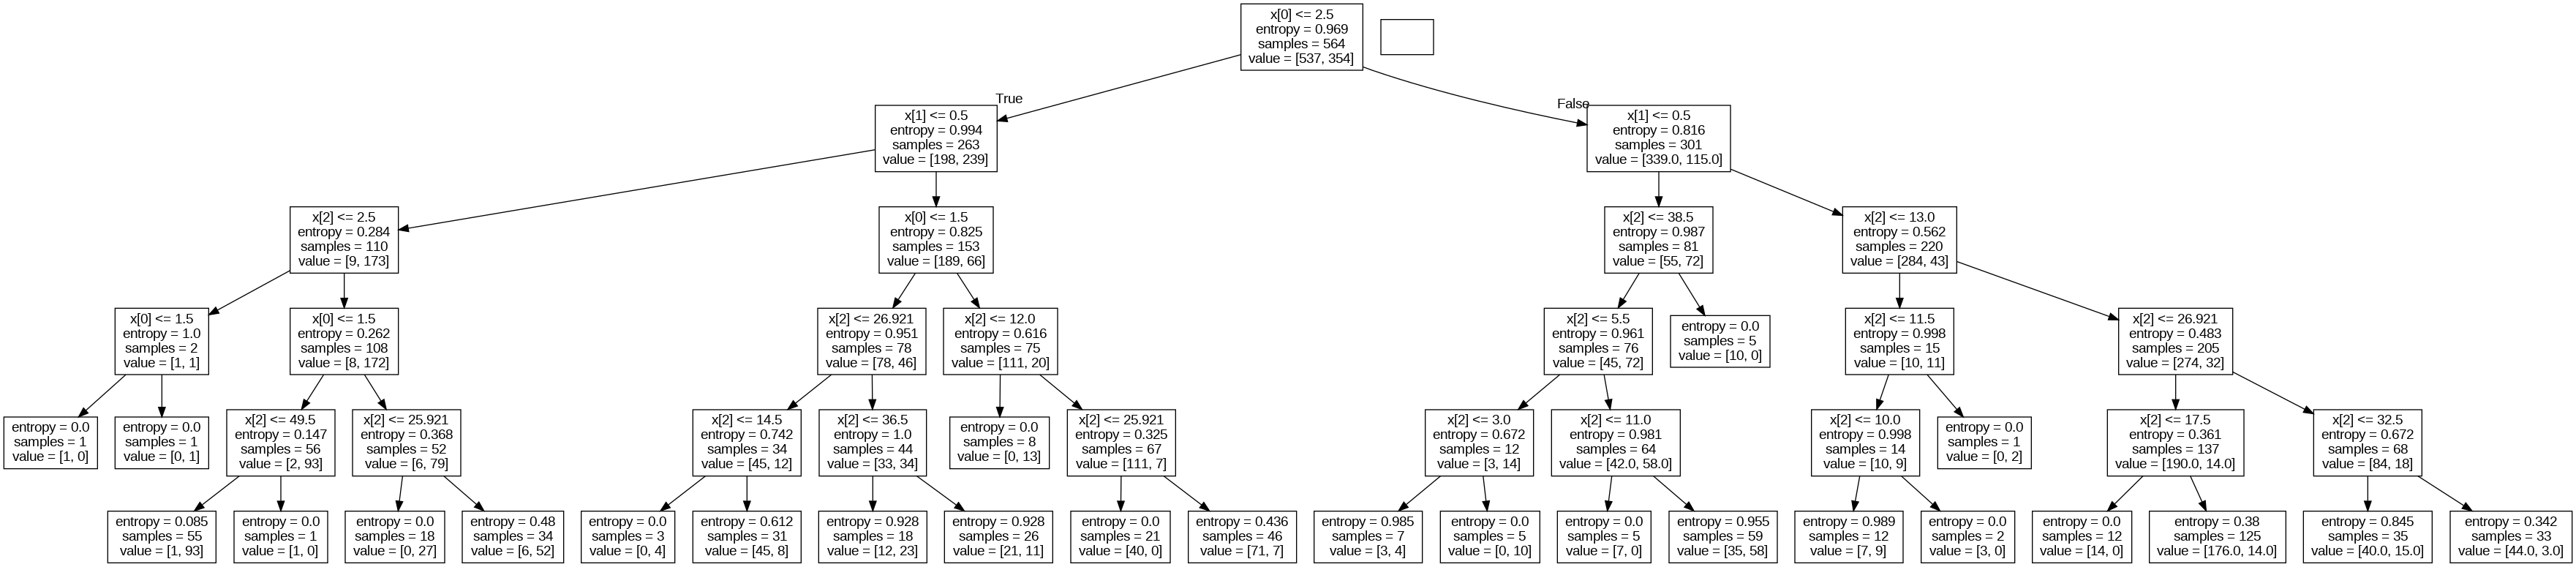

In [17]:
#木の可視化
from sklearn import tree
import pydotplus
from six import StringIO
from IPython.display import Image

dot_data = StringIO()
single_tree = model.estimators_[0]
tree.export_graphviz(single_tree, out_file=dot_data)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

学習させたモデルで，testデータの予測を行います．

In [18]:
#テストデータの予測
y_pred = model.predict(X_test)
y_pred

array([0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

予測した値をgender_submission.csv(提出のサンプルファイル)のSurvivedの列に上書きし，提出用ファイル(submission_titanic1.csv)を作成します．

この後は，作成したファイルをkaggleの所定の場所に提出すればスコアが出るはずです．



In [19]:
#参考の表をコピー．上書きして提出用のcsvを作成
path = '/content/drive/MyDrive/kaggle/titanic/'

submission = pd.read_csv(path + 'gender_submission.csv')
submission['Survived'] = y_pred
submission.to_csv('/content/drive/MyDrive/共有アイテム/submission_titanic1.csv', index=False)
submission.head(20)

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
5,897,0
6,898,0
7,899,0
8,900,1
9,901,0
